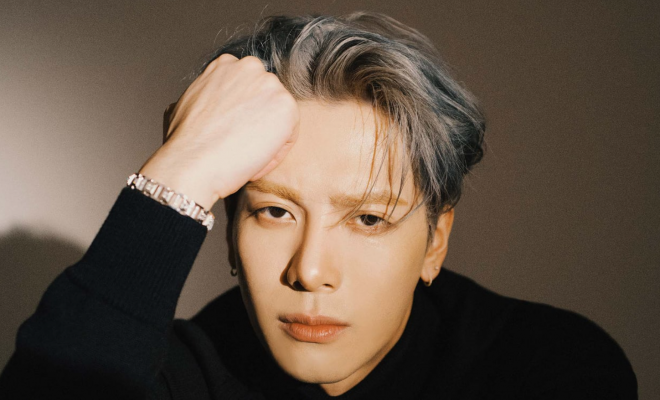

# **CNN Project : Jackson or not Jackson**

## **Introduction**

***Jackson Wang*** est un artiste, chanteur et danseur hongkongais, *membre du groupe GOT7*, un célèbre boys band de K-pop.
Né le *28 mars 1994* à *Hong Kong*.
Avant sa carrière musicale, il était *athlète de niveau national en escrime*.
Connu pour son charisme, son style unique et ses performances scéniques, Jackson est très populaire à l’international.
Il a également une carrière solo réussie, sortant des albums et des singles en Corée, en Chine et à l’international.
Réputé pour son style vestimentaire et son influence mode il est ambassadeur de la maison *Louis Vuitton* mais aussi un entrepreneur agueri avec sa marque de vetement *Team Wang Design*.

### **Dataset** :

Le dataset contient 200 images issues de photos de Jackson Wang et d’autres idols ou images diverses de K-pop :

- Train : 80 images Jackson, 80 images Divers

- Test : 20 images Jackson, 20 images Divers

Chaque image a été redimensionnée à 128x128 pixels et normalisée pour faciliter l’apprentissage. Ce mini-dataset nous permet de réaliser un prototype rapide de classification d’images.

### **Objectif** :

L’objectif est de créer un modèle capable de reconnaître Jackson dans une image parmi d’autres idols.

- Classe 1 : c'est Jackson Wang

- Classe 2 : Ce n'est pas jackson

On est donc sur un problème binaire (True or False);

Nous voulons pouvoir tester rapidement le modèle sur des images non vues pendant l’entraînement et observer la précision du CNN.

### **Pourquoi un CNN ?** :
Un Convolutional Neural Network (CNN) est particulièrement adapté pour la classification d’images car :
- Il peut capturer les motifs spatiaux (yeux, visage, coiffure, vêtements) sans nécessiter de features manuelles.
- Il est plus efficace que les réseaux fully connected classiques pour les images, car il réduit le nombre de paramètres et évite le surapprentissage sur un petit dataset.
- Il est rapide à entraîner pour un petit dataset et permet des prototypes visuellement convaincants.


### Etape 0 : Installation + import

In [18]:
# Installation 

# !pip install tensorflow

In [35]:
# Gestion des fichiers et affichage
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# PyTorch
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Évaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [20]:
# # Pour manipuler les fichiers et chemins
# import os
# import shutil

# # Pour les calculs et manipulations d'images
# import numpy as np
# from PIL import Image
# import matplotlib.pyplot as plt

# # Pour le CNN
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# # Pour évaluation
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


### Etape 1 : Préparation des données et Exploration des données

In [25]:
# Transformations des images
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Datasets
train_data = datasets.ImageFolder('dataset/train', transform=transform)
test_data = datasets.ImageFolder('dataset/test', transform=transform)

# Loaders
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

# Vérif
print(f"Classes détectées : {train_data.classes}")
print(f"Nombre d'images d'entraînement : {len(train_data)}")
print(f"Nombre d'images de test : {len(test_data)}")


Classes détectées : ['divers', 'jackson']
Nombre d'images d'entraînement : 159
Nombre d'images de test : 40


In [26]:
for folder in os.listdir('dataset'):
    print(f"{folder}/ -> {os.listdir(os.path.join('dataset', folder))}")


test/ -> ['divers', 'jackson']
train/ -> ['divers', 'jackson']


In [27]:
for split in ['train', 'test']:
    for cls in ['jackson', 'divers']:
        path = f'dataset/{split}/{cls}'
        count = len(os.listdir(path))
        print(f"{split}/{cls}: {count} images")


train/jackson: 80 images
train/divers: 80 images
test/jackson: 20 images
test/divers: 20 images


In [28]:
# from torch.utils.data import DataLoader

# # Création des DataLoaders
# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
# testloader = DataLoader(test_dataset, batch_size=8, shuffle=False)


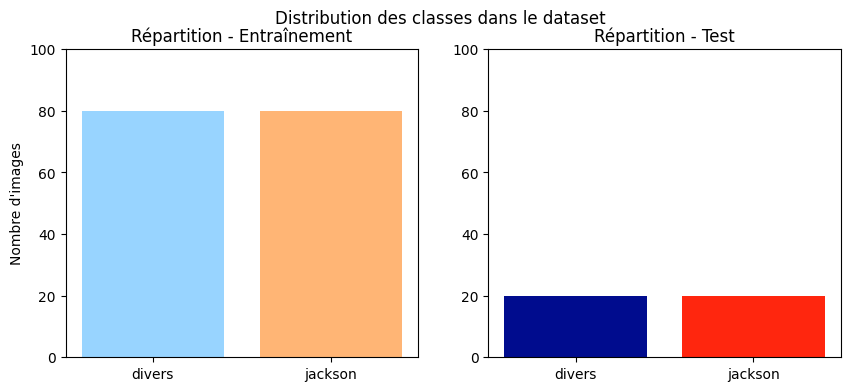


Nombre total d’images d’entraînement : 160
Nombre total d’images de test : 40
Classes : ['divers', 'jackson']


In [38]:
train_counts = [len(os.listdir(f"dataset/train/{cls}")) for cls in train_data.classes]
test_counts = [len(os.listdir(f"dataset/test/{cls}")) for cls in test_data.classes]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Train
ax[0].bar(train_data.classes, train_counts, color=["#98d4ff", "#ffb575"])
ax[0].set_title("Répartition - Entraînement")
ax[0].set_ylabel("Nombre d'images")
ax[0].set_ylim(0, 100)

# Test
ax[1].bar(test_data.classes, test_counts, color=["#000c8e", "#ff260e"])
ax[1].set_title("Répartition - Test")
ax[1].set_ylim(0, 100)

plt.suptitle("Distribution des classes dans le dataset")
plt.show()

print(f"\nNombre total d’images d’entraînement : {sum(train_counts)}")
print(f"Nombre total d’images de test : {sum(test_counts)}")
print(f"Classes : {train_data.classes}")

In [42]:
for split in ['train', 'test']:
    print(f"\n--- {split.upper()} ---")
    for cls in train_data.classes:
        folder = f"dataset/{split}/{cls}"
        sizes = []
        channels_ok = True
        for img_file in os.listdir(folder):
            img_path = os.path.join(folder, img_file)
            img = Image.open(img_path)
            sizes.append(img.size)
            if img.mode != 'RGB':
                channels_ok = False
        widths, heights = zip(*sizes)
        print(f"{cls}: {len(sizes)} images, taille min {min(widths)}x{min(heights)}, max {max(widths)}x{max(heights)}, tous RGB : {channels_ok}")


--- TRAIN ---
divers: 80 images, taille min 168x251, max 736x1385, tous RGB : True
jackson: 80 images, taille min 500x709, max 910x1414, tous RGB : True

--- TEST ---
divers: 20 images, taille min 736x1136, max 736x1635, tous RGB : True
jackson: 20 images, taille min 250x328, max 736x1229, tous RGB : True


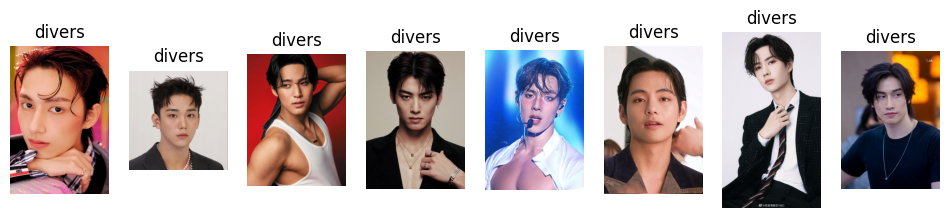

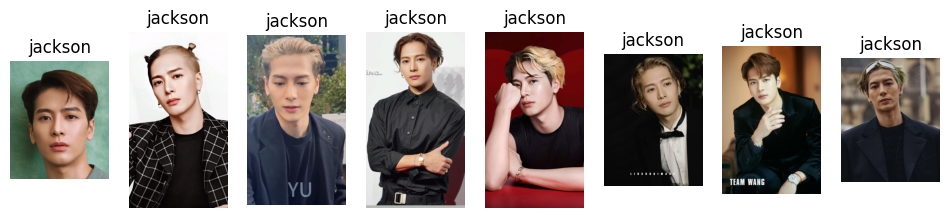

In [43]:
def show_class_images(cls, n=8):
    folder = f"dataset/train/{cls}"
    imgs = os.listdir(folder)[:n]
    plt.figure(figsize=(12,4))
    for i, img_name in enumerate(imgs):
        img = Image.open(f"{folder}/{img_name}")
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')
    plt.show()

for cls in train_data.classes:
    show_class_images(cls)


In [ ]:
def check_images(folder_paths):
    corrupted = []
    for folder in folder_paths:
        for img_file in os.listdir(folder):
            img_path = os.path.join(folder, img_file)
            try:
                img = Image.open(img_path)
                img.verify()
            except (IOError, SyntaxError) as e:
                corrupted.append(img_path)
    return corrupted

# Chemins des dossiers à vérifier
folders_to_check = [
    "dataset/train/jackson", "dataset/train/divers",
    "dataset/test/jackson", "dataset/test/divers"
]

corrupted_images = check_images(folders_to_check)

if corrupted_images:
    print("Images corrompues détectées :")
    for path in corrupted_images:
        print(path)
else:
    print("Aucune image corrompue détectée")

Aucune image corrompue détectée


____

### Etape 2: Construire et entrainer le CNN

In [89]:
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [90]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
model = myCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [91]:
# entrainement 

n_epochs = 10

train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_losses.append(running_loss/total)
    train_accuracies.append(correct/total)

    # Évaluation sur test set
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    test_losses.append(test_loss/total)
    test_accuracies.append(correct/total)

    print(f"Epoch {epoch+1}/{n_epochs} | "
          f"Train loss: {train_losses[-1]:.4f} | Train acc: {train_accuracies[-1]*100:.2f}% | "
          f"Test loss: {test_losses[-1]:.4f} | Test acc: {test_accuracies[-1]*100:.2f}%")

Epoch 1/10 | Train loss: 0.6945 | Train acc: 49.06% | Test loss: 0.6672 | Test acc: 65.00%
Epoch 2/10 | Train loss: 0.6498 | Train acc: 64.15% | Test loss: 0.6470 | Test acc: 60.00%
Epoch 3/10 | Train loss: 0.6073 | Train acc: 68.55% | Test loss: 0.6451 | Test acc: 60.00%
Epoch 4/10 | Train loss: 0.5668 | Train acc: 70.44% | Test loss: 0.6548 | Test acc: 62.50%
Epoch 5/10 | Train loss: 0.5472 | Train acc: 69.18% | Test loss: 0.6642 | Test acc: 60.00%
Epoch 6/10 | Train loss: 0.5164 | Train acc: 73.58% | Test loss: 0.6964 | Test acc: 65.00%
Epoch 7/10 | Train loss: 0.4966 | Train acc: 77.36% | Test loss: 0.6978 | Test acc: 62.50%
Epoch 8/10 | Train loss: 0.4596 | Train acc: 80.50% | Test loss: 0.7100 | Test acc: 60.00%
Epoch 9/10 | Train loss: 0.4371 | Train acc: 78.62% | Test loss: 0.7911 | Test acc: 65.00%
Epoch 10/10 | Train loss: 0.4234 | Train acc: 82.39% | Test loss: 0.7471 | Test acc: 60.00%


**interpretation** : 
`epoch = 10` et `dropout = 0.5` `lr = 0.001`
Le modèle atteint 100% de précision sur le jeu d’entraînement mais seulement 60% sur le jeu de test. Cela montre que le CNN apprend parfaitement les images qu’il connaît, mais ne généralise pas bien à de nouvelles images. Cet écart indique un overfitting, probablement dû à la taille très réduite du dataset. Pour améliorer la précision sur de nouvelles images, il faudrait augmenter les données, simplifier le modèle ou utiliser du transfert d’apprentissage.
*temps= 1min~*

`epoch 100`
Overfitting !!!!!
temps = 14min~

**aperçu** :

```Epoch 97/100 | Train loss: 0.0383 | Train acc: 98.74% | Test loss: 6.4125 | Test acc: 57.50%
Epoch 98/100 | Train loss: 0.0163 | Train acc: 99.37% | Test loss: 4.8660 | Test acc: 62.50%
Epoch 99/100 | Train loss: 0.0026 | Train acc: 100.00% | Test loss: 7.3029 | Test acc: 57.50%
Epoch 100/100 | Train loss: 0.0884 | Train acc: 98.74% | Test loss: 6.2735 | Test acc: 62.50%
```

____

`epoch = 30` et `dropout = 0.6`
- Train loss continue de diminuer fortement → le modèle apprend bien les données d’entraînement.

- Train acc grimpe jusqu’à 100% → il mémorise presque toutes les images d’entraînement.

- Test loss augmente progressivement et Test acc stagne autour de 55–62% → signe que le modèle n’arrive pas à généraliser sur des données qu’il n’a jamais vues, malgré le dropout.

La régularisation par dropout aide à limiter un peu l’overfitting, mais ici la taille du dataset est trop petite
*3min*
____

`lr = 0.0001` `epoch=10`

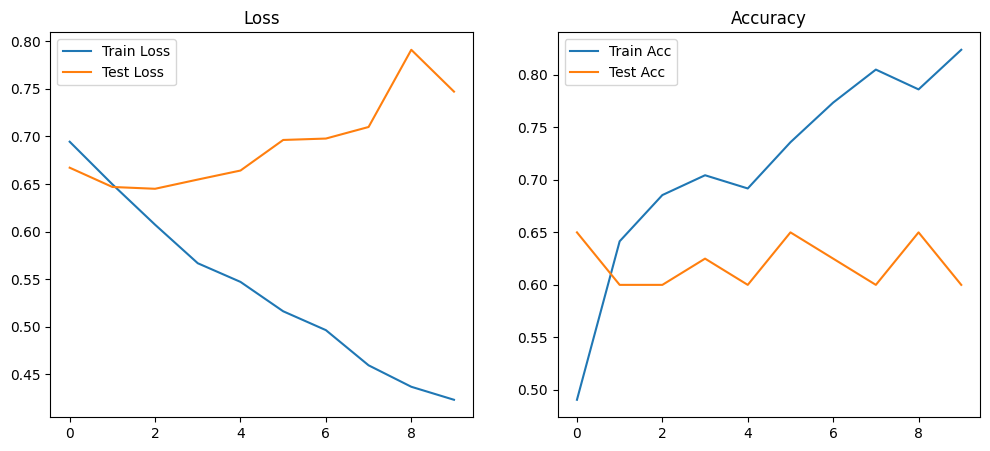

In [92]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(test_accuracies, label='Test Acc')
plt.title("Accuracy")
plt.legend()
plt.show()

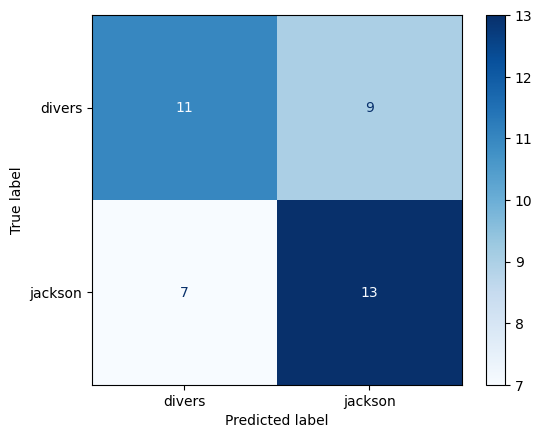

In [93]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=train_data.classes)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [103]:
# Si on réduit la complexiter du model

class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(65536, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [104]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
model = myCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [105]:
# entrainement 

n_epochs = 20

train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_losses.append(running_loss/total)
    train_accuracies.append(correct/total)

    # Évaluation sur test set
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    test_losses.append(test_loss/total)
    test_accuracies.append(correct/total)

    print(f"Epoch {epoch+1}/{n_epochs} | "
          f"Train loss: {train_losses[-1]:.4f} | Train acc: {train_accuracies[-1]*100:.2f}% | "
          f"Test loss: {test_losses[-1]:.4f} | Test acc: {test_accuracies[-1]*100:.2f}%")

Epoch 1/20 | Train loss: 0.7190 | Train acc: 49.69% | Test loss: 0.6520 | Test acc: 60.00%
Epoch 2/20 | Train loss: 0.6107 | Train acc: 67.92% | Test loss: 0.6470 | Test acc: 60.00%
Epoch 3/20 | Train loss: 0.5914 | Train acc: 67.92% | Test loss: 0.6562 | Test acc: 62.50%
Epoch 4/20 | Train loss: 0.5466 | Train acc: 74.21% | Test loss: 0.6801 | Test acc: 60.00%
Epoch 5/20 | Train loss: 0.5155 | Train acc: 76.10% | Test loss: 0.6684 | Test acc: 60.00%
Epoch 6/20 | Train loss: 0.4471 | Train acc: 84.91% | Test loss: 0.6679 | Test acc: 55.00%
Epoch 7/20 | Train loss: 0.4268 | Train acc: 79.87% | Test loss: 0.7128 | Test acc: 65.00%
Epoch 8/20 | Train loss: 0.3704 | Train acc: 85.53% | Test loss: 0.6823 | Test acc: 57.50%
Epoch 9/20 | Train loss: 0.3580 | Train acc: 84.91% | Test loss: 0.7255 | Test acc: 62.50%
Epoch 10/20 | Train loss: 0.3160 | Train acc: 89.31% | Test loss: 0.7432 | Test acc: 62.50%
Epoch 11/20 | Train loss: 0.2709 | Train acc: 91.19% | Test loss: 0.7147 | Test acc: 62.5

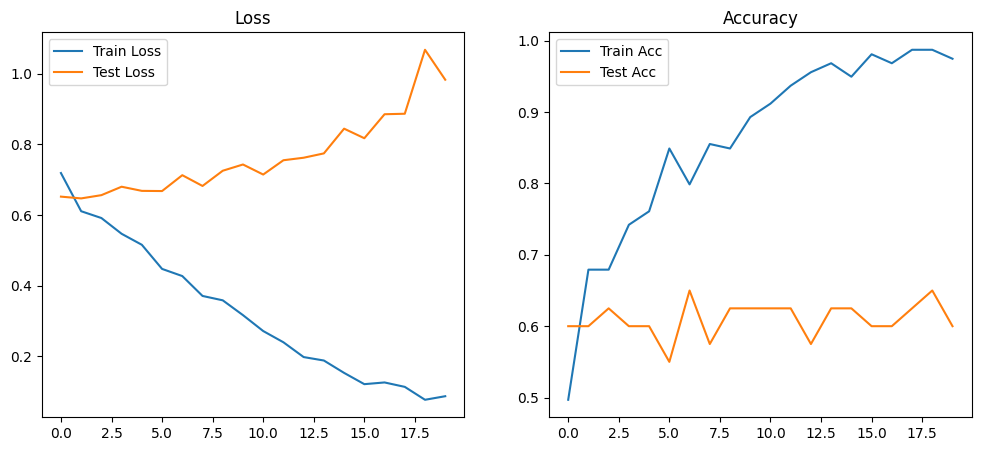

In [106]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(test_accuracies, label='Test Acc')
plt.title("Accuracy")
plt.legend()
plt.show()

**interpretation** : toujours overfitting meme si on simplifie le model